# Hands-on 01: Uso de modelos de propagação para análises sistêmicas

### Objetivos
As metas desse tutorial são ajudar o usuário na:
- Criação de Grid Hexagonal para modelar cobertura de Estações Rádio Base
- Análise visual de potência recebida 
- Análise de Outage de potência
- Exercitar programação de front-end para visualização de dados
- Criar códigos em Python para o back-end


## Prática 01: Sobreamento descorrelacionado

Vamos escrever um código para criação do mapa de cobertura (REM) das 7 (sete) estações rádio base (ERBs), como ilustrado na figura a seguir.


![fig_hex](../FIGS/HD_01_MATLAB/fig_hex.png)


A modelagem tem as seguintes características:

- Grid com células hexagonais;
- ERBs macrocelulares com altura de 30 m;
- Estações móveis com altura média de 1,8 m;
- O raio de cada hexágono é um parâmetro ajustável denominado dR;
- As dimensões do grid celular com as 7 ERBs é 5dR x 6 $\sqrt{\frac{3}{4}}$ dR;
- Para fins de definição da Outage (falha da conexão por falta de potência), a sensibilidade do receptor é considerada igual a -104 dBm ([fonte](http://www.comlab.hut.fi/opetus/260/1v153.pdf));
- A EIRP (Effective Isotropic Radiated Power) é 57 dBm ([Discussão interessante sobre $P_{TX}$ e EIRP](https://under-linux.org/entry.php?b=1384)). Esse valor é compatível com receptores do GSM ([fonte](https://pt.slideshare.net/naveenjakhar12/gsm-link-budget));
- Somente a perda de percurso é considerada como manifestação de canal. Assim, a potência recebida será calculada com o modelo de Okumura-Hata para cidades urbanas grandes;
- A frequência da portadora é um parâmetro ajustável denominado dFc;
- Para evitar problema numéricos (divisão por zero ou logaritmo de zero), vamos modelar um raio de segurança. Para efeito de cálculo da potência recebida, todos os pontos menores que uma distância denominada dRMin, terão potência recebida igual aquela calculada usando dRMin como distância;
- **Sombreamento independente em cada ponto de medição, não importando a distância entre eles.**

A ideia é calcular a potência recebida em dBm para pontos equidistantes em toda a ára de cobertura. A distância entre os pontos de medição foi definida como o próximo valor inteiro maior que $\frac{dR}{20}$. Esse valor pode ser ajustado para melhor visualizar os REMs. 

**Passo 01:** O segunte código servirá para desenhar um hexágono de centro e raio especificados como parâmetro. Tal função servirá para termos certeza que o posicionamento das ERBs estão corretos.

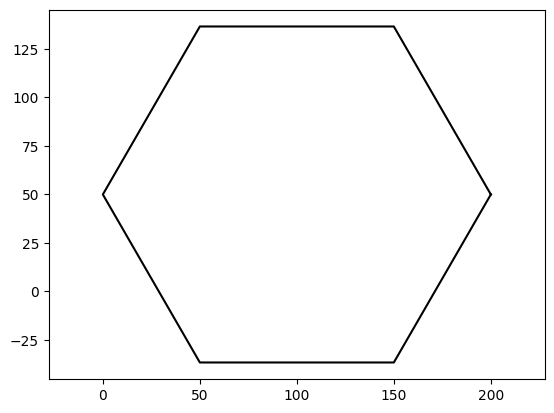

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def fDrawSector(dR, dCenter):
    vtHex = []
    for ie in range(1, 7):
        angle = (ie - 1) * np.pi / 3
        vtHex.append(dR * (np.cos(angle) + 1j * np.sin(angle)))
    vtHex = np.array(vtHex) + dCenter
    vtHexp = np.append(vtHex, vtHex[0])  # adiciona o primeiro ponto ao final para fechar o hexágono
    plt.plot(vtHexp.real, vtHexp.imag, 'k')  # plota apenas as partes real e imaginária
    plt.axis('equal')  # mantém as proporções iguais no gráfico
    plt.show()


# Para testar a função, você pode chamar fDrawSector com um raio e um centro específicos, por exemplo:
fDrawSector(100, 100 + 50j)

**Passo 02:** O segunte código servirá para desenhar o grid celular. Tal função servirá para termos certeza que o posicionamento das ERBs estão corretos.

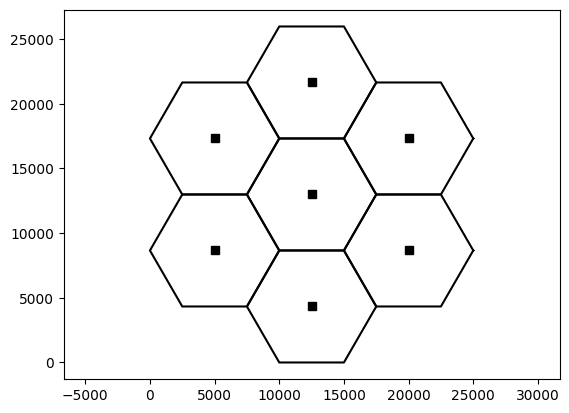

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# Função para desenhar os setores hexagonais
def fDrawSector(dR, dCenter):
    vtHex = []
    for ie in range(1, 7):
        angle = (ie - 1) * np.pi / 3
        vtHex.append(dR * (np.cos(angle) + 1j * np.sin(angle)))
    vtHex = np.array(vtHex) + dCenter
    vtHexp = np.append(vtHex, vtHex[0])
    plt.plot(vtHexp.real, vtHexp.imag, 'k')

# Função para desenhar o grid hexagonal de raio definido por parâmetro e com BSs no centro definidos por vetor de posições das BSs 
def fDrawDeploy(dR, vtBs):
    # Desenha setores hexagonais
    plt.figure()
    plt.gca().set_aspect('equal', adjustable='box')
    for iBsD in range(len(vtBs)):
        fDrawSector(dR, vtBs[iBsD])
    # Plota as bases (BSs)
    plt.plot([bs.real for bs in vtBs], [bs.imag for bs in vtBs], 'sk')
    #plt.show()

# Chamar funções criadas para desenhar o grid hexagonal e as bases (BSs)
# Parâmetros do hexágono
dR = 5e3  # Raio do Hexágono
dIntersiteDistance = 2 * np.sqrt(3 / 4) * dR  # Distância entre ERBs
dDimX = 5 * dR  # Dimensão X do grid
dDimY = 6 * np.sqrt(3 / 4) * dR  # Dimensão Y do grid
# Vetor com posições das BSs (grid Hexagonal com 7 células, uma célula central e uma camada de células ao redor)
vtBs = [0]
dOffset = np.pi / 6
for iBs in range(2, 8):
    angle = (iBs - 2) * np.pi / 3 + dOffset
    vtBs.append(dR * np.sqrt(3) * np.exp(1j * angle))
# Ajuste de posição das bases (posição relativa ao canto inferior esquerdo)
vtBs = np.array(vtBs) + (dDimX / 2 + 1j * dDimY / 2)
# Função para desenhar os setores hexagonais (assumindo que fDrawDeploy e fDrawSector já foram implementados)
fDrawDeploy(dR, vtBs)
plt.axis('equal')
plt.show()

**Passo 03:** Inspecione o código, ele cria um vetor com a posição das 7 ERBs. A posição é ajustada para que a referência, i.e., o ponto (0,0) seja o canto inferior esquerdo do grid. O raio de cada hexágono foi ajustado para o perfeito encaixe no grid de 7 ERBs.

## Prática 02: Cálculo e plot da potência recebida sem e com shadowing

Vamos escrever um código para o cálculo da potência recebida nos pontos de medição do REM de cada ERB, e também considerando a composição das 7 ERBs. Como especificado no hands-on, precisamos considerar que a potência recebida de cada ponto de medição é a maior potência recebida em relação às 7 ERBs.

**Passo 01:** Inspecione, insira o código a seguir. Nesse código, vamos:

- Criar sete matrizes de distâncias relativas de cada ponto de medição e para cada ERB (matrizes **mtDistEachBs**). Aplicaremos o raio de segurança a essas distâncias;
- Com as distâncias, usar o modelo de Okumura-Hata para calcular a perda de percurso (matrizes **mtPldB**);
- Sortear baseado em uma distribiução Lognormal amostras independentes do Sombreamento para cada ponto de medição (matrizes **mtShadowing**);
- Com as matrizes de EIRP, da perda de percurso e do sombreamento, calcular a potência recebida de cada ERB em cada ponto de medição. Para cada ERB montaremos a matriz **mtPowerEachBSdBm**;
- Montar uma única matriz **mtPowerFinaldBm** com a maior potência recebida em cada ponto de medição;
- Plotar o REM de cada ERB e da composição das 7 ERBs.

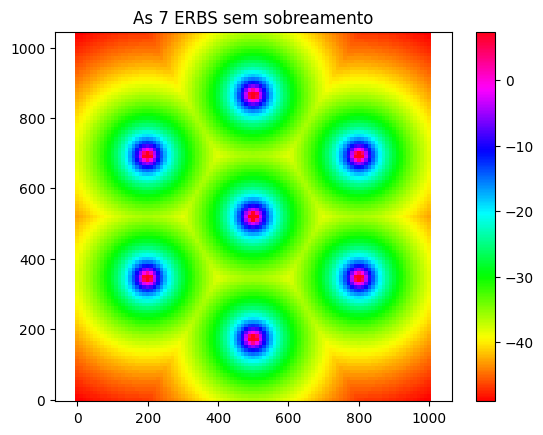

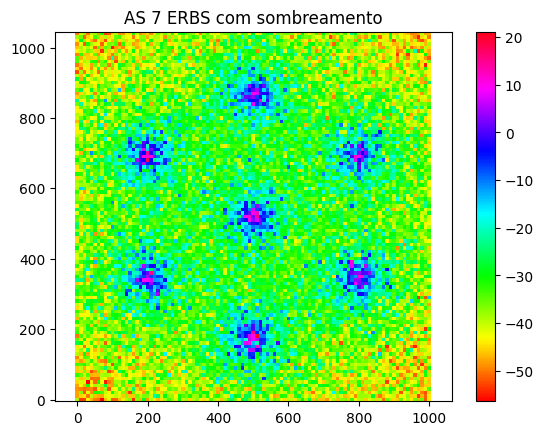

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Input parameters
dR = 200                                                    # Radius of the hexagon
dFc = 800                                                   # Carrier frequency
dShad = 50                                                  # Shadowing decorrelation distance
dSigmaShad = 8                                              # Lognormal shadowing standard deviation
dPasso = 10                                                 # Grid resolution: measurement point distance
dRMin = dPasso                                              # Minimum radius
dIntersiteDistance = 2 * np.sqrt(3 / 4) * dR                # Inter-BS distance (for info)
dDimXOri = 5 * dR                                           # X dimension of the grid
dDimYOri = 6 * np.sqrt(3 / 4) * dR                          # Y dimension of the grid
dPtdBm = 57                                                 # EIRP including gains and losses
dPtLinear = 10 ** (dPtdBm / 10) * 1e-3                      # EIRP in linear scale
dHMob = 5                                                   # Receiver height
dHBs = 30                                                   # Transmitter height
dAhm = 3.2 * (np.log10(11.75 * dHMob))**2 - 4.97            # Okumura-Hata model: large city, fc >= 400MHz
# BS positions (Hexagonal grid with 7 cells, one central and one layer around)
vtBs = [0]
dOffset = np.pi / 6
for iBs in range(2, 8):
    vtBs.append(dR * np.sqrt(3) * np.exp(1j * ((iBs - 2) * np.pi / 3 + dOffset)))
vtBs = np.array(vtBs) + (dDimXOri / 2 + 1j * dDimYOri / 2)  # Position adjustment (relative to bottom left corner)
# Reference grid position matrix (relative to bottom left corner)
dDimY = int(np.ceil(dDimYOri + dDimYOri % dPasso))
dDimX = int(np.ceil(dDimXOri + dDimXOri % dPasso))
mtPosx, mtPosy = np.meshgrid(np.arange(0, dDimX + 1, dPasso), np.arange(0, dDimY + 1, dPasso))
mtPontosMedicao = mtPosx + 1j * mtPosy
# Initialize matrix with maximum received power at each point
mtPowerFinaldBm = -np.inf * np.ones_like(mtPosy)
mtPowerFinalShaddBm = -np.inf * np.ones_like(mtPosy)
# Calculate REM for each BS and accumulate the highest power at each measurement point
for iBsD in range(len(vtBs)):
    # 3D matrix of measurement points for each BS as complex numbers X + jY
    mtPosEachBS = mtPontosMedicao - vtBs[iBsD]
    mtDistEachBs = np.abs(mtPosEachBS)                      # Distance between each point and its BS
    mtDistEachBs[mtDistEachBs < dRMin] = dRMin              # Minimum radius implementation
    # Okumura-Hata model (urban city) - dB
    mtPldB = 69.55 + 26.16 * np.log10(dFc) + (44.9 - 6.55 * np.log10(dHBs)) * np.log10(mtDistEachBs / 1e3) - 13.82 * np.log10(dHBs) - dAhm
    mtShadowing = dSigmaShad * np.random.randn(*mtPosy.shape)   # Independent shadowing at each point
    # Received power at each measurement point without shadowing
    mtPowerEachBSdBm = dPtdBm - mtPldB
    mtPowerFinaldBm = np.maximum(mtPowerFinaldBm, mtPowerEachBSdBm)
    # Received power at each measurement point with independent shadowing
    mtPowerEachBSShaddBm = dPtdBm - mtPldB + mtShadowing
    mtPowerFinalShaddBm = np.maximum(mtPowerFinalShaddBm, mtPowerEachBSShaddBm)
# Plot REM without shadowing
plt.figure()
plt.pcolormesh(mtPosx, mtPosy, mtPowerFinaldBm, shading='auto', cmap='hsv')
plt.colorbar()
plt.axis('equal')
plt.title('As 7 ERBS sem sobreamento')
# Plot REM with independent shadowing
plt.figure()
plt.pcolormesh(mtPosx, mtPosy, mtPowerFinalShaddBm, shading='auto', cmap='hsv')
plt.colorbar()
plt.axis('equal')
plt.title('AS 7 ERBS com sombreamento')
plt.show()

**A execução do código resulta em:**
1. Dois mapas REMs mostrando o grid celular e a potência recebida nos pontos de medição para as 7 ERBS;
2. Foi utilizado um colormap diferente da primeria parte do hands-on para diferenciar melhor os níveis de potência e as diferentes cores que o representa;
2. A situação com e sem sombreamento estão identificadas no título de cada gráfico;
3. Note que a distribuição de potência deixa de ser uniforme e radial quando o sombreamento está presente.

**Analise o código com cuidado. Tente compreender a modelagem e a sintaxe usada. Discuta com os colegas. Faça um debug usando a IDE do Matlab.**

##  Entrega 1: Modelagem e avaliação da inclusão de microcélulas

Uma solução tecnológica para tratar problemas de cobertura é o uso de repetidores (microcélulas, picocélulas) com intuito de estender o alcance de uma estrutura macrocelular (torres altas e com alta potência). Considere o uso de microcélulas com as seguintes características:

  - Potência de transmissão: 0.1 W
  - Perda de percurso: PL = 55 + 38 $\cdot$ log$_{10}$(d)+ (24.5 + $\frac{1.5*f}{925}$)*log$_{10}$(f), com d em km e f em MHz;
   
O sistema não é multi-conectividade, i.e., a potência de um ponto NÃO é a SOMA da potência da melhor macrocélula com a microcélula. Assim, como um usuário está conectado ou a macrocélula ou a microcélula, ao final você terá somente uma matriz de potências recebidas.

Considere -90 dBm como potência mínima de operação, i.e., um usuário (ou ponto no grid) é bloqueado se sua potência recebida for menor que esse valor. Outra consideração importante é que os usuários estão conectados a melhor estação rádio base. Faça os mapas com resolução espacial de 50 m. Se necessário, essa resolução pode ser diminuída, para melhor visualização da cobertura das microcélulas.


Seu alvo é analisar 3 cenários:

  - (i) Sistema somente com perda de percurso (sem shadowing), f = 800 MHz, ht = 32m e hr= 1,5m, raio do hexágono 500m;
  - (ii) Sistema somente com perda de percurso (sem shadowing), f = 1800 MHz, ht = 32m e hr= 1,5m, raio do hexágono 500m;
  - (iii) Sistema somente com perda de percurso (sem shadowing), f = 2100 MHz, ht = 32m e hr= 1,5m, raio do hexágono 500m;
  

Prepare um primeiro conjunto de resultados, ainda sem microcélulas, e com a potência da macrocélula igual a 21 dBm. Eles são:

 - REMs com somente de duas cores, identificando: (i) a área de Outage do mapa (cor 1); e (ii) área com potência maior que a mínima (cor 2). Fazer 3 REMs, uma para cada cenário. Analise esses gráficos e decida qual o melhor posicionamento da suas seis microcélulas. 
 
 - Comparando as frequências, discuta se as áreas de outage mudaram, e se essa mudança a fez escolher posicionamento diferentes para microcélulas, dependendo da frequência da portadora;

De posse do primeiro conjunto de resultados, posicione seis (somente seis) microcélulas nos pontos estratégicos escolhidos por você. A figura a seguir mostra um exemplo de posicionamento de seis microcélulas. Será que algumas dessas posições são realmente as mais aconselhadas para resolver o problema da Outage?

![fig_shadcorr_mod_zoom_300](../FIGS/HD_01_MATLAB/microcelulas.png)

Compare os resultados com a situação sem a microcélulas. Quais as principais observações e diferenças?

Agora com as microcélulas inteligentemente posicionadas por você, faça um segundo conjunto de resultados com:

 - Os mesmos 3 REMs, mas agora com a inclusão das microcélulas (um REM para cada frequência da portadora). Compare os REMS com e sem microcélula para cada cenário;
 - Fazer um gráfico de barras (pode ser no Microsoft Excel, por exemplo) da outage com e sem microcélula para cada cenário.

 Compare os resultados com a situação sem a microcélulas. Quais as principais observações e diferenças? inclua figuras e discussão na sua entrega.